<table style="width:100%; font-size:11pt; border-collapse:collapse">
    <tr>
        <td colspan="2"
            style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   text-align:center;
                   font-weight:bold;
                   padding:8px;">
            Universidad de Oriente
        </td>
    </tr>
    <tr>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
                            Machine Learning
        </td>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
            Clase 3: Estadística robusta
        </td>
    </tr>
    <tr>
 

</table>

## Ejercicio 1

- Comprobar la normalidad a una muestra obtenida mediante el muestreo aleatorio 
de una distribución normal con media $\mu=0.05$ y desviación típica $\sigma=0.99$  $n=1000$.

- Comprobar la normalidad a una muestra obtenida mediante el muestreo aleatorio
de una distribución normal con media $\mu=0.05$ y desviación típica $\sigma=0.9$ y $n=10000$.

In [1]:
import pandas as pd
import numpy as np
from pandas.core.common import flatten
from plotnine import *
from array import *
import scipy.stats as stats
import math
import matplotlib as mpl
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn import linear_model
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms

Una vez cargadas las librerías ya se puede simular la muestra y realizar sobre la misma la prueba de normalidad:

In [9]:
# Definir semilla para que los resultados sean los mismos
np.random.seed(seed = 2026)

#Se definen los parametros de la distribucion normal
mu, sigma = 0.05, 0.9

#Se obtiene la muestra estandarizada
muestra = np.random.normal(mu, sigma, 1000)

#Se realiza la prueba
sh_result = stats.shapiro(muestra)
#Dar formato a la salida

print("Estadístico: %5.3f, p.valor: %5.3f" %(sh_result.statistic,sh_result.pvalue))

Estadístico: 0.999, p.valor: 0.949


El resultado sale mayor que 0.05 y por lo tanto se acepta la hipotesis nula de normalidad de la muestra.

b) Como el tamaño de muestra es mayor que 5000, la Prueba de Shapiro-Wilk no es tan recomendable. En cambio, se puede realizar las pruebas de normalidad en Python utilizando la función kstest de la librería scipy.stats. La muestra se obtiene con la función np.random.normal, la cual se vió en el tema 1. La Prueba de Kolmogorov- Smirnov realmente necesita comparar entre dos distribuciones. Así pues, se compara la muestra con la distribución normal pasando como argumentos la media y la
desviación típica.

In [13]:
#Definir semilla para que los resultados sean los mismos
np.random.seed(seed = 2026)

#Se definen los parametros de la distribucion normal
mu, sigma = 0.05, 0.9

#Se obtiene la muestra
muestra_2 = np.random.normal(mu, sigma, 10000)

#Se realiza la prueba
ks_result = stats.kstest(muestra_2, "norm", args = (mu,sigma))

#Dar formato a la salida----------------------------------------
print("estadístico: %5.3f, p.valor: %5.3f" %(ks_result.statistic,ks_result.pvalue))

estadístico: 0.012, p.valor: 0.134


Como el p-valor de la Prueba de Shapiro-Wilk es mucho mayor de 0.05 se considera que la distribución cumple la normalidad de manera estadísticamente significativa. A continuación, en la figura se muestra un gráfico q-q donde se corrobora visualmente dicha normalidad.

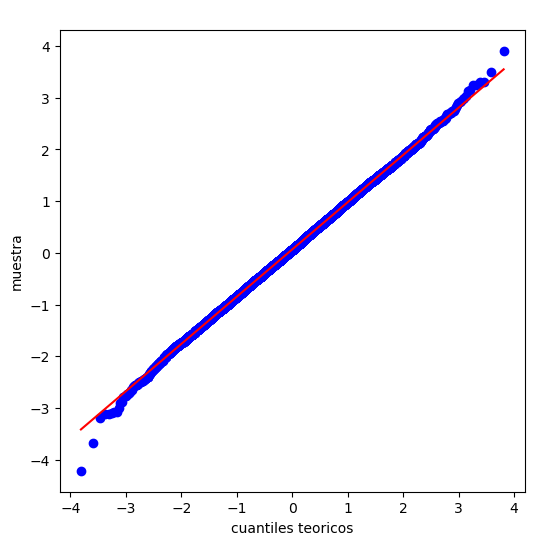

In [16]:
# definir dimensiones de la figura-------------------------------
fig = plt.figure(figsize=(6,6))
qqplot = stats.probplot(muestra_2, dist = "norm", plot = plt)
plt.xlabel("cuantiles teoricos")
plt.ylabel("muestra")
plt.title(" ")
plt.show()

## Ejercicio 2

Simular lo siguiente:

- Una muestra $\varepsilon$ de $n = 500$ de una distribución normal con media $\mu = 0$ y desviación
típica $\sigma=1$.
- Una muestra $x$ de $n = 500$ de una distribución uniforme $[0, 200]$

Construir las muestras $Y1$ e $Y2$ que sean igual a:
\begin{align*}
Y1&=100+200x+ \varepsilon x \\
Y2&=100+200x+\varepsilon
\end{align*}

- Obtener un modelo de regresión lineal $Y = \beta_0 + \beta_1 x$ para $Y1$ e $Y2$ y
representa gráficamente los residuos de los modelos
- Realiza la prueba de Breusch-Pagan para cada uno de los modelos

Se generan las muestras del ejercicio y se construyen las muestras $Y1$ e $Y2$. Posteriormente
se realizan los modelos de regresión y se muestran gráficamente los
residuos. Por el modo en que están construidas ambas muestras, $Y1$ tendrá unos
residuos crecientes con X mientras que para $Y2$ los residuos serán homogéneos
para todo el rango de variación de X.

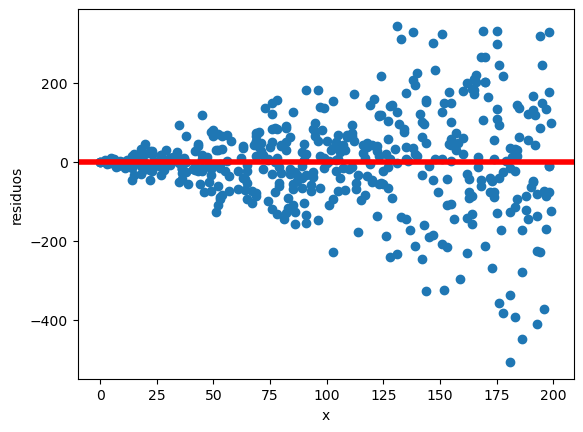

In [20]:
#Definir semilla para que los resultados sean los mismos
np.random.seed(seed = 2026)

#Se obtiene la muestra normal
muestra_normal = np.random.normal(0, 1, 500)
muestra_unif = np.random.randint(0, 200, 500)

#Para la muestra y1
y1 = 100+200*muestra_unif+muestra_normal * muestra_unif

#Se necesita trasponer el vector x
x = muestra_unif.reshape((-1, 1))
lm1 = linear_model.LinearRegression()
model1 = lm1.fit(x, y1)

#Obtener valores modelo
y_pred1 = model1.predict(x)
#Obtener residuos
residuos1 = y1 - y_pred1

#Para la muestra y2
y2 = 100+200*muestra_unif+muestra_normal
lm2 = linear_model.LinearRegression()
model2 = lm2.fit(x, y2)

#Obtener valores modelo
y_pred2 = model2.predict(x)
#Obtener residuos
residuos2 = y2 - y_pred2

plt.scatter(x, residuos1)
plt.axhline(0, color = "red", linewidth = 4)
plt.xlabel("x")
plt.ylabel("residuos")
plt.show()

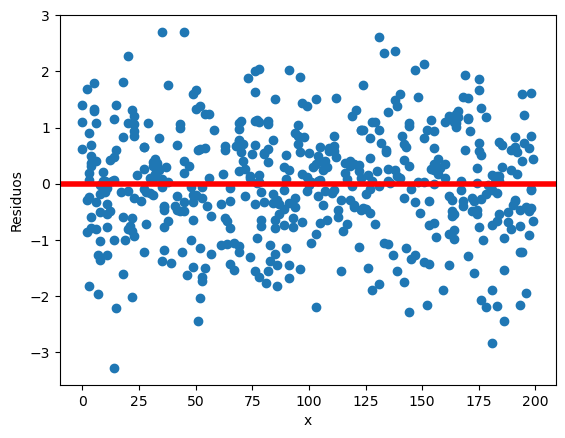

In [21]:
plt.scatter(x, residuos2)
plt.axhline(0, color = "red", linewidth = 4)
plt.xlabel("x")
plt.ylabel("Residuos")
plt.show()

In [21]:
m1 = sm.OLS(y1, sm.add_constant(x)).fit()
bp1 = sms.het_breuschpagan(resid = m1.resid, exog_het = m1.model.exog)[1]
print("El resultado del test Breusch-Pagan es: p.valor = %5.3f"%(bp1))

El resultado del test Breusch-Pagan es: p.valor = 0.000


In [23]:
m2 = sm.OLS(y2, sm.add_constant(x)).fit()
bp2 = sms.het_breuschpagan(resid = m2.resid, exog_het = m2.model.exog)[1]
print("El resultado del test Breusch-Pagan es: p.valor = %5.3f"%(bp2))

El resultado del test Breusch-Pagan es: p.valor = 0.751


## Ejercicio 3

Se tiene la siguiente muestra $X=\{4,3,11,5,4,50,6,8,7,9 \}$, en el que el valor 50 es un outlier

a) Calcular la media recortada de la muestra al 20\%, al 10\% y calcula la centrimedia

b) Calcular la media winsorizada al 20 %.

c) Calcular la trimedia

d) Compara los valores obtenidos en los apartados a), b) y c) con la media muestral.

e) Calcula el MAD y comparalo con la desviación típica

a) Para calcular las medias recortadas, se eliminan los datos una vez ordenados por cada extremo y se calcula la media. Para recortar un 20 % ($\alpha = 0.2$), se recorta un 10 % (un valor) en cada extremo y se calcula la media. Para recortar un 10 % ($\alpha =0.1$), se pondera los valores de los extremos con 0.5 y se calcula la media
considerando que $n=9$. Por último, para obtener la centrimedia se eliminan 2 valores de cada extremo, se pondera por 0.5 el tercer y el octavo valor y se obtiene la media considerando $n = 5$.

In [24]:
#Definir la muestra
X = np.array([4, 3, 11, 5, 4, 50, 6, 8, 7, 9])

#Ordenar los valores de la muestra
X.sort()
print(X)

[ 3  4  4  5  6  7  8  9 11 50]


In [26]:
#Quitar valores recortados 0.1
X1 = X[1:9]
print(X1)
print("La media recortada al 20 % es", X1.mean())

[ 4  4  5  6  7  8  9 11]
La media recortada al 20 % es 6.75


In [28]:
#Quitar valores recortados 0.05
X2 = np.array([3*0.5, 4, 4, 5, 6, 7, 8, 9, 11, 50*0.5])
print("La media recortada al 10 % es",round(sum(X2)/9, 2))

La media recortada al 10 % es 8.94


In [30]:
#Quitar valores recortados 0.25 (centrimedia)
X3 = X[2:8]
# print(X3)
X3[0] = 4*0.5
X3[5] = 8*0.5
print("La centrimedia es", sum(X3)/5)

La centrimedia es 6.4


b) Para obtener la media winsorizada, en lugar de eliminar las observaciones, se sustituyenpor los últimos valores. Es análogo a las medias recortadas excepto en que las
puntuaciones que se eliminaban ahora se sustituyen por los valores menor y mayor que quedan para el cómputo de la media winsorizada.

In [33]:
#Definir la muestra
X = np.array([4, 3, 11, 5, 4, 50, 6, 8, 7, 9])

#Ordenar los valores de la muestra
X_ord = X.sort()
# print(X_ord)

# quitar valores recortados 0.1
W1 = np.array([4, 4, 4, 5, 6, 7, 8, 9, 11, 11])
W1[0],W1[-1] = W1[1],W1[-2]
# print(W1)
print("La media winsorizada es", sum(W1)/10)

La media winsorizada es 6.9


c) La trimedia se obtiene ponderando la mediana y el primer y tercer cuartil según
la fórmula:

$$\text{trimedia} = \dfrac{\text{cuartil 1}+2 \text{cuartil 2} +\text{cuartil 3}}{4}$$

In [36]:
#Definir la muestra
X = np.array([4, 3, 11, 5, 4, 50, 6, 8, 7, 9])

#Ordenar los valores de la muestra
X.sort()
q1_x = np.quantile(X, 0.25, interpolation='midpoint') #Cuartil 1
me_x = np.quantile(X, 0.50, interpolation='midpoint') #Cuartil 2
q3_x = np.quantile(X, 0.75, interpolation='midpoint') #Cuartil 3

trimedia = (q1_x+2*me_x+q3_x)/4
print("La trimedia es %s" %trimedia)

La trimedia es 6.5


d) Se obtiene la media muestral

In [40]:
#Definir la muestra
X = np.array([4, 3, 11, 5, 4, 50, 6, 8, 7, 9])

#Ordenar los valores de la muestra
X.sort()
print("La media muestral es", X.mean())

La media muestral es 10.7


La media muestral es 10.7, que es mucho más sensible al outlier de 50, que los métodos
robustos obtenidos en los apartados a, b y c.

e) Para calcular el MAD es necesario calcular la mediana de la diferencia absoluta de
cada valor con la mediana de la muestra.

In [6]:
print("La mediana de la muestra vale me_x = ", me_x)

La mediana de la muestra vale me_x =  6.5


In [10]:
#Construir vector diferencias absolutas
AD = abs(X-me_x)
MAD = np.quantile(AD, 0.5, interpolation = "midpoint")
print("El MAD vale", MAD)

El MAD vale 2.5


In [12]:
print("La desviación típica es", round(X.std(), 1))

La desviación típica es 13.3


Se observa que el MAD es mucho más insensible a valores atípicos que la desviación típica de la muestra.